# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javier Pinochet
- Nombre de alumno 2: Daniel Muñoz

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/danmc899/MDS7202)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. El conjunto de prueba se utiliza para entrenar los modelos, en cambio, el conjunto de validación se usa para seleccionar el mejor modelo al ir variando sus hiperparámetros.

2. El principal desafío del aprendizaje no supervisado es carecer de una función o variable objetivo y aún así lograr comprender la distribución o forma de los datos.

3. Una matriz de confusión es una repressentación visual donde dada una lista de clases a la que puede pertenecer unos datos, grafica la razón en que un dato es clasificado como su clase real o como las demás clases.

4.

*   Accuracy: Es la tasa de correctos sobre todas las predicciones.

$accuracy = \frac{predicciones\ correctas}{predicciones\ totales}$


*   Precision: Dada una clase, calcula la tasa de clasificados correctamente como esa clase en razón a los predichos para esa clase.

$precision = \frac{clasificados\ correctamente\ positivos}{total\ predichos\ positivos}$

*   Recall: Dada una clase, calcula la tasa de clasificados correctamente como esa clase en razón a los realmentes pertenecientes a esa clase.

$recall = \frac{clasificados\ correctamente\ positivos}{total\ reales\ positivos}$

*   F1 score: Es la media armónica entre la precision y el recall

$F = \frac{2\cdot precision\cdot recall}{precision+ recall}$


5.

* Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera: Recall, porque se quiere evitar que una maquina que vaya a fallar no sea clasificada como tal (falsos negativos).
* Detección de enfermedades altamente contagiosas: Recall, porque lo riesgoso es la existencia de falsos negativos, es decir, los predichos como no enfermos pero en la realidad si lo son.
* Aprobación de créditos de alto riesgo: Precision, porque se busca minimizar aprobar a alguien riesgos, es decir los falsos positivos.
* Detección de crímenes: F1-score, porque se quiere atrapar a los reales criminales pero sin enjuiciar a personas inocentes.

6. La calibración de modelo es una técnica con la cual se ajustan las probabilidades de salida de un clasificador para que den cuenta de las reales probabilidades de que un objeto pertenezca a cierta clase.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [1]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [2]:
import numpy as np
import pandas as pd
from time import perf_counter
import datetime
from IPython.display import HTML

# Libreria para plotear (En colab esta desactualizado plotly)
#!pip install --upgrade plotly
import plotly.express as px
import plotly.graph_objects as go

# Librerias utiles
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

df = pd.read_csv("C:\\Users\\javpi\\Downloads\\Lab5 (2)\\stats_players.csv")
df.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


In [3]:
df.columns

Index(['Name', 'Nationality', 'National_Position', 'Club_Position', 'Height',
       'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot',
       'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys'],
      dtype='object')

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [4]:
# 1.
df["label"] = np.where(df["National_Position"].isna(), 0, 1)
df

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,95,85,92,93,90,81,76,85,88,1
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,68,71,85,95,88,89,90,74,85,1
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,61,62,78,89,77,79,84,81,83,1
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,69,77,87,94,86,86,84,85,88,1
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,78,25,25,13,16,14,11,47,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17583,Adam Dunbar,Republic of Ireland,NaN,Sub,183,82,Right,19,Medium / Medium,1,...,56,14,16,13,13,11,13,15,12,0
17584,Dylan McGoey,Republic of Ireland,NaN,Sub,185,80,Right,19,Medium / Medium,2,...,53,12,17,12,11,12,13,16,12,0
17585,Tommy Ouldridge,England,NaN,Res,173,61,Right,18,High / Medium,2,...,61,41,44,28,42,35,36,42,37,0
17586,Mark Foden,Scotland,NaN,Sub,180,80,Right,21,Medium / Medium,3,...,48,15,23,14,12,13,12,24,12,0


In [5]:
# 2.
df["label"].value_counts()

label
0    16513
1     1075
Name: count, dtype: int64

In [6]:
df.columns

Index(['Name', 'Nationality', 'National_Position', 'Club_Position', 'Height',
       'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot',
       'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys', 'label'],
      dtype='object')

In [7]:
# 3.

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

df.drop(columns=["Name"], inplace=True)
df.drop(columns=['Nationality'], inplace=True)
df.drop(columns=['National_Position'], inplace=True)
# Definicion las variables que pasarán por cada pipeline
# categorical_cols= ['National_Position', 'Club_Position',  'Preffered_Foot', 'Work_Rate']
categorical_cols= ['Club_Position',  'Preffered_Foot', 'Work_Rate']
numeric_cols_std= ['Height','Weight','Weak_foot','Age',
       'Skill_Moves', 'Ball_Control',  'Aggression', 'Reactions',  'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys']
numeric_cols_minmax= ['Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle','Interceptions']


col_transformer = ColumnTransformer(
    transformers=[
        ("num_std", StandardScaler(), numeric_cols_std),
        ("num_minmax", MinMaxScaler(), numeric_cols_minmax),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="passthrough"  # para conservar el resto de columnas
)



4. Primeramente, se eliminaron las columnas "Name", "Nationality" y "National_Position"; la primeras 2 porque no aportan al problema y tienen una alta cardinalidad (según el html), y la tercera porque su existencia aseguraría que siempre se prediga lo correcto, lo que no tendría sentido para resolver el problema.

Luego, se seleccionaron variables categóricas, y se les aplicó OneHotEncoder para convertir sus diferentes valores en variables numéricas.
También, a la mayoría de las variables numéricas, en especial, las que tenían un comportamiento normal en su distribución, se les aplicó StandardScaler para estandarizar a varianza 1; mientras que las que tenían más bien un comportamiento bimodal se les aplicó MinMax para reescalar los datos pero sin perder su forma.

In [8]:
df

,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,Ball_Control,Dribbling,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
0,LW,185,80,Right,32,High / Low,4,5,93,92,...,95,85,92,93,90,81,76,85,88,1
1,RW,170,72,Left,29,Medium / Medium,4,4,95,97,...,68,71,85,95,88,89,90,74,85,1
2,LW,174,68,Right,25,High / Medium,5,5,95,96,...,61,62,78,89,77,79,84,81,83,1
3,ST,182,85,Right,30,High / Medium,4,4,91,86,...,69,77,87,94,86,86,84,85,88,1
4,GK,193,92,Right,31,Medium / Medium,4,1,48,30,...,78,25,25,13,16,14,11,47,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17583,Sub,183,82,Right,19,Medium / Medium,1,1,12,11,...,56,14,16,13,13,11,13,15,12,0
17584,Sub,185,80,Right,19,Medium / Medium,2,1,13,11,...,53,12,17,12,11,12,13,16,12,0
17585,Res,173,61,Right,18,High / Medium,2,2,44,39,...,61,41,44,28,42,35,36,42,37,0
17586,Sub,180,80,Right,21,Medium / Medium,3,1,17,13,...,48,15,23,14,12,13,12,24,12,0


### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [9]:
# df = df[~df.isin(["Sub", "Res"]).any(axis=1)]

In [10]:
# 1.
from sklearn.model_selection import train_test_split

X = df.drop(columns="label")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          #
    random_state=42,        #
    stratify=y              #
)

In [11]:
X_train

,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,Ball_Control,Dribbling,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
11928,Res,175,65,Left,21,Medium / Medium,3,3,63,65,...,72,55,47,63,60,52,59,53,64,57
13540,Sub,182,76,Left,21,Medium / Medium,3,3,60,63,...,70,55,40,60,55,45,64,60,49,49
6268,Sub,168,70,Right,28,Low / High,3,2,72,65,...,74,90,65,70,59,68,65,66,55,44
14602,Res,171,69,Right,18,Medium / Medium,3,2,61,60,...,72,62,47,54,43,43,60,49,56,48
3581,Sub,177,72,Left,27,Medium / Medium,3,2,66,59,...,68,75,70,59,31,45,57,39,35,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5590,GK,185,84,Right,25,Medium / Medium,1,1,15,16,...,45,67,20,14,11,18,16,12,25,8
6777,LM,182,72,Right,25,Medium / Medium,4,3,59,64,...,70,91,64,71,64,66,72,73,65,56
16199,Sub,184,85,Right,24,Medium / Medium,2,1,18,19,...,38,59,19,16,19,18,20,18,27,11
4129,CB,190,83,Right,27,Medium / High,2,2,42,30,...,61,76,72,40,40,27,13,36,52,23


In [12]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline con XGBoost
pipeline_xgboost = Pipeline([
    ("preprocessing", col_transformer),
    ("classifier", XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

# Pipeline con LightGBM
pipeline_lightgbm = Pipeline([
    ("preprocessing", col_transformer),
    ("classifier", LGBMClassifier(
        random_state=42
    ))
])

# 3.
# Entrenamiento
pipeline_xgboost.fit(X_train, y_train)
pipeline_lightgbm.fit(X_train, y_train)

C:\Users\javpi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [22:40:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2530
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_std', StandardScaler(),
                                                  ['Height', 'Weight',
                                                   'Weak_foot', 'Age',
                                                   'Skill_Moves',
                                                   'Ball_Control', 'Aggression',
                                                   'Reactions', 'Vision',
                                                   'Composure', 'Crossing',
                                                   'Short_Pass', 'Long_Pass',
                                                   'Acceleration', 'Speed',
                                                   'Stamina', 'Strength',
                                                   'Balance', 'Agility',
                                                   'Jumping', 'Heading',
                                                   'Shot_Power', 'Finishing',
                                                   'Long_Shots', 'Curve',
                                                   'Freekick_Accuracy',
                                                   'Penalties', 'Volleys']),
                                                 ('num_minmax', MinMaxScaler(),
                                                  ['Dribbling', 'Marking',
                                                   'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Interceptions']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Club_Position',
                                                   'Preffered_Foot',
                                                   'Work_Rate'])])),
                ('classifier', LGBMClassifier(random_state=42))])

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [13]:
# 1.

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Predicciones
y_pred_xgb  = pipeline_xgboost.predict(X_test)
y_pred_lgbm = pipeline_lightgbm.predict(X_test)

# XGBoost
print("=== XGBoost ===")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, pos_label=1))
print("Recall   :", recall_score(y_test, y_pred_xgb,    pos_label=1))
print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb, digits=3))

# LightGBM
print("\n=== LightGBM ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm, pos_label=1))
print("Recall   :", recall_score(y_test, y_pred_lgbm,    pos_label=1))
print("\nClassification report:")
print(classification_report(y_test, y_pred_lgbm, digits=3))

=== XGBoost ===
Accuracy : 0.938601478112564
Precision: 0.4925373134328358
Recall   : 0.15348837209302327

Classification report:
              precision    recall  f1-score   support

           0      0.947     0.990     0.968      3303
           1      0.493     0.153     0.234       215

    accuracy                          0.939      3518
   macro avg      0.720     0.572     0.601      3518
weighted avg      0.919     0.939     0.923      3518


=== LightGBM ===
Accuracy : 0.9394542353610006
Precision: 0.5192307692307693
Recall   : 0.12558139534883722

Classification report:
              precision    recall  f1-score   support

           0      0.946     0.992     0.969      3303
           1      0.519     0.126     0.202       215

    accuracy                          0.939      3518
   macro avg      0.732     0.559     0.585      3518
weighted avg      0.920     0.939     0.922      3518



2. Los valores de las métricas en ambos modelos son realmente muy parecidos, así que se comentarán como un conjunto:
* El accuracy es muy alto, lo que indica que hay una buena tasa de predicciones correctas en razón a las totales.
* La precisión para la clase positiva es del orden del 50%, por tanto, hay una gran porción de falsos positivos, o sea, jugadores no seleccionados clasificados como seleccionables; para la clase negativa, el rendimiento es mucho mejor, aunque esto se explica por los pocos datos positivos en comparación a los negativos.
* El recall es demasiado bajo para la calse positiva, lo que indica que se identifica alrededor del 15% de los realmente positivos, por tanto hay muchos falsos positivos, esto puede deberse a la gran cantidad de reales negativos; mientras que para la clase negativa, el rendimiento nuevamente es mucho mejor, pero de nuevo por el desbalance de los datos negativos en comparación a los positivos.


3. Cómo se quiere reclutar a jugadores que sean seleccionados, lo mejor es evitar falsos positivos, es decir jugadores predichos como seleccionados pero que realmente no lo son. Por ello la métrica más adecuada para este problema es la Precision.
En base a eso, el modelo que tiene el mejor desempeño, sobre todo considerando, los positivos, es LightGBM con un 51,9%.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [14]:
# 1.
df = df[~df.isin(["Sub", "Res"]).any(axis=1)]


pos_map = {
    'ataque': ['ST', 'CF'],
    'central_ataque': ['RW', 'CAM', 'LW'],
    'central': ['RM', 'CM', 'LM'],
    'central_defensa': ['RWB', 'CDM', 'LWB'],
    'defensa': ['RB', 'CB', 'LB'],
    'arquero': ['GK']
}


mapping = {pos: grupo for grupo, lista in pos_map.items() for pos in lista}


df_nuevo = df.copy()
df_nuevo['label'] = df_nuevo['Club_Position'].map(mapping)


label = df_nuevo['label']

**¿Por qué XGBoost?**

Hay más de 50 datos, se quiere predecir una categoría, hay datos etiquetados, por ello es un problema de clasificación, hay menos de 100.000 datos, pero al ser datos de texto, y al tener experiencia con este tipo de clasificadores, se ha escogido un clasificador de Ensemble, XGBoost en particular.

In [15]:
dfnulos= df_nuevo[df_nuevo["label"].isna()]
dfnulos

,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,Skill_Moves,Ball_Control,Dribbling,...,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,label
12,RCM,174,65,Right,31,High / Medium,4,4,92,86,...,67,55,73,71,82,79,77,80,74,NaN
15,LCB,183,79,Right,32,High / High,3,3,80,68,...,93,82,78,38,71,61,73,71,63,NaN
16,LCB,183,75,Right,31,High / Medium,3,3,83,61,...,92,90,79,60,55,73,67,68,66,NaN
18,LCM,191,84,Right,24,High / Medium,4,5,90,89,...,85,73,90,71,88,82,82,76,84,NaN
19,RS,176,67,Left,26,High / Medium,3,4,86,87,...,87,80,81,88,82,84,75,71,87,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17170,LCM,185,70,Right,20,Medium / Medium,3,3,54,59,...,60,39,55,47,43,45,38,54,47,NaN
17287,LCM,168,57,Left,21,Medium / Medium,3,3,45,49,...,51,37,54,41,39,44,39,41,39,NaN
17295,LCM,185,75,Right,18,Medium / High,3,2,49,47,...,64,43,41,32,34,39,35,37,28,NaN
17461,LCM,172,72,Right,20,Medium / Medium,3,2,48,48,...,63,57,48,50,54,42,33,69,40,NaN


In [16]:
# 2.
df_nuevo['label'].value_counts()

label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64

In [17]:
# df_nuevo.isnull().sum()
df_nuevo.columns

Index(['Club_Position', 'Height', 'Weight', 'Preffered_Foot', 'Age',
       'Work_Rate', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling',
       'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression',
       'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing',
       'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina',
       'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power',
       'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties',
       'Volleys', 'label'],
      dtype='object')

In [18]:
# 3.

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()


df_nuevo= df_nuevo.dropna()
X = df_nuevo.drop(columns=["label", "Club_Position"])
y = df_nuevo["label"]
y = le.fit_transform(y)
# print(X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          #
    random_state=42,        #
    stratify=y              #
)


categorical_cols= [ 'Preffered_Foot', 'Work_Rate']
numeric_cols_std= ['Height','Weight','Weak_foot','Age',
       'Skill_Moves', 'Ball_Control',  'Aggression', 'Reactions',  'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys']
numeric_cols_minmax= ['Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle','Interceptions']


col_transformer = ColumnTransformer(
    transformers=[
        ("num_std", StandardScaler(), numeric_cols_std),
        ("num_minmax", MinMaxScaler(), numeric_cols_minmax),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="passthrough"
)


# Pipeline utilizando ensamble de árboles
pipeline_xgb = Pipeline([
    ("preprocessor", col_transformer),
    ("classifier", XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

# Entrenamiento
pipeline_xgb.fit(X_train, y_train)

# Predicciones
y_pred = pipeline_xgb.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

C:\Users\javpi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [22:40:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7436548223350253
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.76      0.81      0.79        86
        central       0.60      0.60      0.60       182
 central_ataque       0.48      0.41      0.44       116
central_defensa       0.39      0.17      0.23        42
        defensa       0.84      0.95      0.89       236

       accuracy                           0.74       788
      macro avg       0.68      0.66      0.66       788
   weighted avg       0.72      0.74      0.73       788



4.
* El accuracy es del 74%, lo que es decente para 6 clases.
* Los aqrqueros parecen ser una clase muy fácil de distinguir en base a sus cualidades.
* Los defensas (y un poco menos lo atacantes) pueden ser distinguibles de los demás con un rendimiento aceptable,
* Los centrales de ataque y de defensa son muy difíciles de distinguir de los demás tipos de jugadores, probablemente compartan variables entre si o con otras clases más como los mismos centrales, atacantes o defensas.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

In [19]:
from pycaret.classification import *
import os
import pandas as pd

#os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí
# 1.
categorical_cols= ['Club_Position',  'Preffered_Foot', 'Work_Rate']
# Configurar el entorno de PyCaret
s = setup(
	data=df,
	target='label',
	session_id=123,
	numeric_features=numeric_cols_std + numeric_cols_minmax,
	categorical_features=categorical_cols,
	verbose=False
)

# Comparar modelos de árbol
tree_models = ['et', 'rf', 'dt', 'xgboost', "lightgbm", 'catboost']
models = compare_models(include=tree_models, sort='Precision', n_select=1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9209,0.8275,0.1167,0.6861,0.1978,0.1783,0.2594,0.4810
catboost,CatBoost Classifier,0.9233,0.8428,0.2064,0.6595,0.3116,0.2827,0.3381,0.8280
rf,Random Forest Classifier,0.9207,0.8200,0.1580,0.6299,0.2502,0.2242,0.2862,0.3040
lightgbm,Light Gradient Boosting Machine,0.9198,0.8330,0.2042,0.5873,0.2999,0.2679,0.3118,67.3170
xgboost,Extreme Gradient Boosting,0.9182,0.8207,0.2185,0.5400,0.3085,0.2739,0.3067,0.1660
dt,Decision Tree Classifier,0.8666,0.6056,0.2914,0.2524,0.2686,0.1961,0.1976,0.0220


Explicación de los modelos solicitados:

- dt (Decision Tree): Árbol de decisión único. Divide recursivamente el espacio de features eligiendo en cada nodo el split que más reduce la impureza (Gini/entropía). Ventajas: interpretable, inferencia muy rápida. Contras: alta varianza, tiende a sobreajustar sin poda/regularización.

- rf (Random Forest): Ensamble de muchos árboles (dt) entrenados sobre bootstrap samples; en cada nodo se evalúa solo un subconjunto aleatorio de features. Predice por votación mayoritaria. Ventajas: reduce varianza y sobreajuste, robusto, buen desempeño por defecto. Contras: menos interpretable que un árbol, más costo de cómputo/memoria al entrenar.

- et (Extra Trees / Extremely Randomized Trees): Similar a Random Forest pero introduce más aleatoriedad en los splits: los umbrales se eligen aleatoriamente (y a menudo sin bootstrap). Esto reduce aún más la correlación entre árboles y la varianza; suele ser más rápido (menos búsqueda del “mejor” umbral) y a veces rinde igual o mejor que RF. Contras: algo más de sesgo, menos interpretabilidad.

In [20]:
et = create_model('et')
et_tuned = tune_model(et, optimize='Precision')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9199,0.8243,0.1220,0.6250,0.2041,0.1816,0.2517
1,0.9199,0.8228,0.1463,0.6000,0.2353,0.2092,0.2690
2,0.9302,0.8694,0.1707,1.0000,0.2917,0.2738,0.3983
3,0.9158,0.8038,0.0714,0.6000,0.1277,0.1114,0.1864
4,0.9158,0.7856,0.0952,0.5714,0.1633,0.1421,0.2087
5,0.9280,0.7826,0.1463,1.0000,0.2553,0.2389,0.3683
6,0.9115,0.7926,0.0244,0.2500,0.0444,0.0299,0.0543
7,0.9239,0.9175,0.1707,0.7000,0.2745,0.2497,0.3211
8,0.9218,0.8532,0.0976,0.8000,0.1739,0.1585,0.2625


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9220,0.8248,0.0732,1.0000,0.1364,0.1263,0.2597
1,0.9158,0.7791,0.0976,0.5000,0.1633,0.1396,0.1935
2,0.9240,0.8724,0.0976,1.0000,0.1778,0.1653,0.3001
3,0.9179,0.8272,0.0952,0.6667,0.1667,0.1483,0.2309
4,0.9158,0.7933,0.0714,0.6000,0.1277,0.1114,0.1864
5,0.9198,0.8212,0.0488,1.0000,0.0930,0.0858,0.2118
6,0.9136,0.8183,0.0244,0.3333,0.0455,0.0343,0.0706
7,0.9198,0.8925,0.1220,0.6250,0.2041,0.1815,0.2517
8,0.9218,0.8447,0.0732,1.0000,0.1364,0.1263,0.2596


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [21]:
# Panel interactivo y gráficos clave
evaluate_model(et_tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

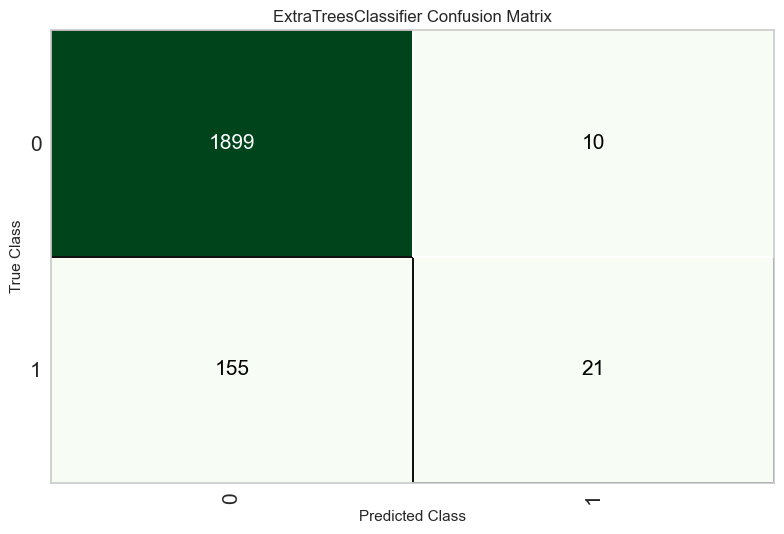

TPR/Recall: 0.119 | TNR/Specificity: 0.995 | Precision: 0.677


In [22]:
plot_model(et_tuned, plot='confusion_matrix')

# Métricas en holdout + TPR/TNR
from sklearn.metrics import confusion_matrix, precision_score
X_hold = get_config('X_test')
y_hold = get_config('y_test')
pred_hold = predict_model(et_tuned, data=X_hold)

y_pred = pred_hold['prediction_label'] if 'prediction_label' in pred_hold.columns else pred_hold['Label']
tn, fp, fn, tp = confusion_matrix(y_hold, y_pred).ravel()
tpr = tp / (tp + fn)   # Recall
tnr = tn / (tn + fp)   # Specificity
print(f"TPR/Recall: {tpr:.3f} | TNR/Specificity: {tnr:.3f} | Precision: {precision_score(y_hold, y_pred):.3f}")

La tasa de verdaderos positivos es baja = 11.9%, es decir, existe una gran cantidad de falsos negativos. Por otro lado, la tasa de verdaderos negativos = 99.5% es muy alta, lo que indica que existe una baja cantidad de falsos positivos, lo que es bueno para el objetivo del problema.

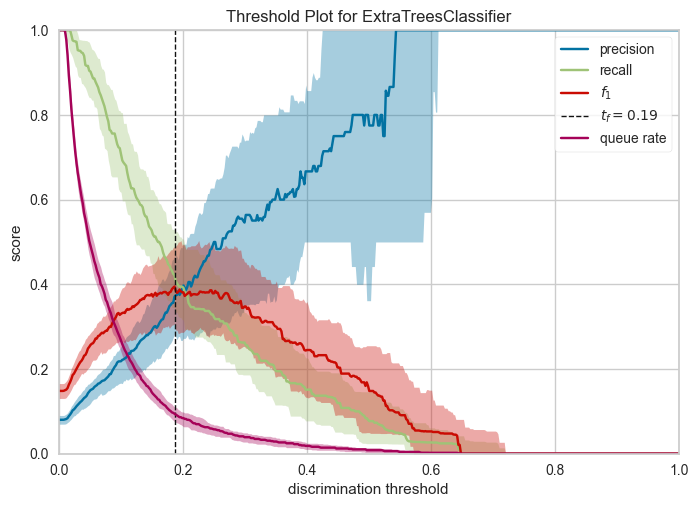

In [23]:
plot_model(et_tuned, plot='threshold')

Solamente es el mejor para f1-score, ya que el treshold lo corta en su máximo. Esto es malo, ya que se quiere minimizar los falsos positivos, por tanto, la métrica más importante es la precision, en la cual no es mala ~ 40%. La sugerencia es en torno al 50%, ya que precision alcanza su máximo ahí, mientras que las demás métricas siguen en picada a la baja.

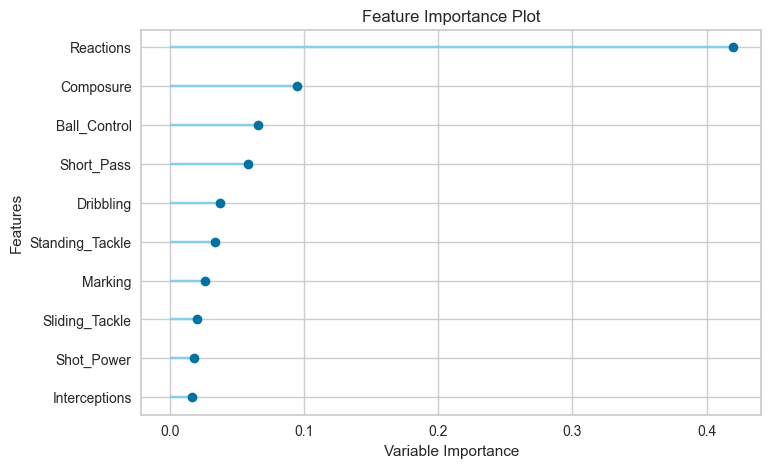

In [24]:
plot_model(et_tuned, plot='feature')

Las mejores tres features son: Reactions, Composure y Ball_Control. Esto puede deberse a que estas variables están más relacionadas con las habilidades técnicas, las estadísticas y la toma de decisiones en el campo, que son cruciales para que el jugador pueda ser seleccionado.

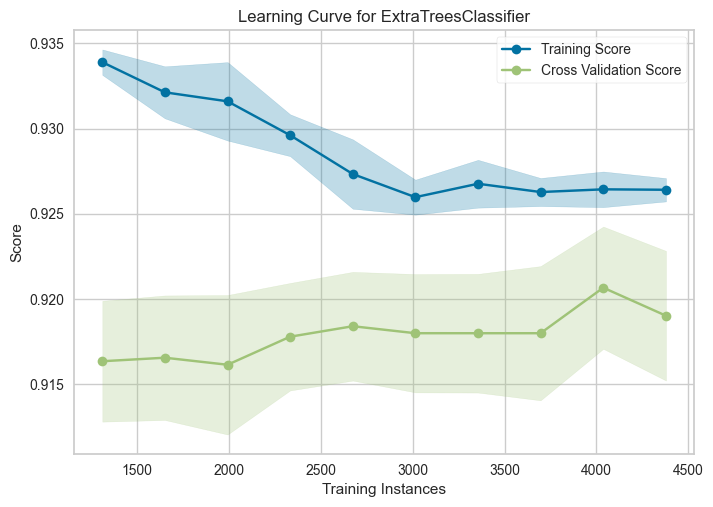

In [25]:
plot_model(et_tuned, plot='learning')

No existe un problema aparente, ya que la curva de aprendizaje muestra que tanto el error de entrenamiento como el de validación convergen a medida que aumenta el tamaño del conjunto de entrenamiento, mientras que mantienen una brecha. Esto indica que el modelo está aprendiendo de manera efectiva y no presenta signos evidentes de sobreajuste o subajuste.

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [26]:
# XGBoost
from xgboost import XGBClassifier
import time

# Features y target
X = df.drop(columns=["label"])
y = df["label"]

# Holdout estratificado
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols_full = ['Club_Position', 'Preffered_Foot', 'Work_Rate'] # Incluye Club_Position

col_transformer_full = ColumnTransformer(
    transformers=[
        ("num_std", StandardScaler(), numeric_cols_std),
        ("num_minmax", MinMaxScaler(), numeric_cols_minmax),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols_full),
    ],
    remainder="passthrough"  # evita pasar columnas objeto sin transformar
)

pipeline_xgb_full = Pipeline([
    ("preprocessing", col_transformer_full),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])
# Entrenamiento
pipeline_xgb_full.fit(X_train2, y_train2)

# Evaluación
y_pred_full = pipeline_xgb_full.predict(X_test2)
print("Accuracy :", accuracy_score(y_test2, y_pred_full))
print("Precision:", precision_score(y_test2, y_pred_full, pos_label=1))
print("Recall   :", recall_score(y_test2, y_pred_full, pos_label=1))
print("\nClassification report:")
print(classification_report(y_test2, y_pred_full, digits=3))

# Importancias de características (orden descendente)
feature_names = pipeline_xgb_full.named_steps["preprocessing"].get_feature_names_out()
importances = pipeline_xgb_full.named_steps["classifier"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_df.head(10)

Accuracy : 0.920863309352518
Precision: 0.6
Recall   : 0.2033898305084746

Classification report:
              precision    recall  f1-score   support

           0      0.930     0.987     0.958      1272
           1      0.600     0.203     0.304       118

    accuracy                          0.921      1390
   macro avg      0.765     0.595     0.631      1390
weighted avg      0.902     0.921     0.903      1390



,feature,importance
0,cat__Club_Position_GK,0.111899
1,num_std__Reactions,0.069785
2,cat__Club_Position_CDM,0.032662
3,cat__Club_Position_LS,0.026633
4,cat__Club_Position_LCB,0.020452
5,cat__Club_Position_RW,0.019649
6,num_std__Composure,0.018106
7,num_minmax__Dribbling,0.017376
8,num_std__Short_Pass,0.017309
9,num_minmax__Standing_Tackle,0.017134


In [27]:
# Reducción iterativa de características. Acá se hace el paso 3 y 4 a la vez.
preprocesador = pipeline_xgb_full.named_steps["preprocessing"]
X_train_transformado = pd.DataFrame(
    preprocesador.transform(X_train2),
    columns=preprocesador.get_feature_names_out()
)
X_test_transformado = pd.DataFrame(
    preprocesador.transform(X_test2),
    columns=preprocesador.get_feature_names_out()
)

# Esto lo debemos hacer todo el rato con las variables que van quedando. Por eso lo metemos en una función
def entrenar_y_evaluar(columnas):
    modelo = XGBClassifier(
        n_estimators=400, # árboles
        max_depth=6, # profundidad máxima, mayor ajuste (riesgo de sobreajuste)
        learning_rate=0.05, # tasa de aprendizaje, menor tasa, más sobreajuste y lentitud de entrenamiento
        subsample=0.8, # evitar sobreajuste
        colsample_bytree=0.8, # evitar sobreajuste
        random_state=42,
        eval_metric="logloss", # métrica de evaluación continua
        n_jobs=-1
    )
    modelo.fit(X_train_transformado[columnas], y_train2)
    predicciones = modelo.predict(X_test_transformado[columnas])
    return modelo, {
        "accuracy": accuracy_score(y_test2, predicciones),
        "precision": precision_score(y_test2, predicciones, pos_label=1),
        "recall": recall_score(y_test2, predicciones, pos_label=1)
    }

lista_caracteristicas = importance_df["feature"].tolist()
modelo_base, metricas_base = entrenar_y_evaluar(lista_caracteristicas)
print(f"Baseline -> Acc: {metricas_base['accuracy']:.3f} | Prec: {metricas_base['precision']:.3f} | Rec: {metricas_base['recall']:.3f}")
# Reporte de clasificación baseline
y_pred_base = modelo_base.predict(X_test_transformado[lista_caracteristicas])
print("\nReporte de clasificación (baseline):")
print(classification_report(y_test2, y_pred_base, digits=3))

# Parámetros de parada propuestos para cada feature quitado
perdida_max_prec = 0.035
perdida_max_recall = 0.03

umbral_prec = metricas_base["precision"] - perdida_max_prec
umbral_recall = metricas_base["recall"] - perdida_max_recall

caracteristicas_actuales = lista_caracteristicas.copy()
mejor_conjunto = lista_caracteristicas.copy()
mejores_metricas = metricas_base
precision_prev = metricas_base["precision"]
recall_prev = metricas_base["recall"]

for caracteristica in reversed(lista_caracteristicas):
    caracteristicas_actuales.remove(caracteristica)
    _, metricas_actuales = entrenar_y_evaluar(caracteristicas_actuales)
    # Criterio de parada: si precisión o recall caen bajo sus umbrales, se detiene
    if (
        metricas_actuales["precision"] < umbral_prec
        or metricas_actuales["recall"] < umbral_recall
    ):
        break
    mejor_conjunto = caracteristicas_actuales.copy()
    mejores_metricas = metricas_actuales
    precision_prev = metricas_actuales["precision"]
    recall_prev = metricas_actuales["recall"]

eliminadas = len(lista_caracteristicas) - len(mejor_conjunto)
print(f"\nSe eliminaron {eliminadas} características.")
print(f"\nMejor subconjunto ({len(mejor_conjunto)} features) -> "
      f"Acc: {mejores_metricas['accuracy']:.3f} | Prec: {mejores_metricas['precision']:.3f} | Rec: {mejores_metricas['recall']:.3f}")

modelo_reducido, _ = entrenar_y_evaluar(mejor_conjunto)
predicciones_reducidas = modelo_reducido.predict(X_test_transformado[mejor_conjunto])
print("\nReporte de clasificación (mejor subconjunto):")
print(classification_report(y_test2, predicciones_reducidas, digits=3))

Baseline -> Acc: 0.917 | Prec: 0.523 | Rec: 0.195

Reporte de clasificación (baseline):
              precision    recall  f1-score   support

           0      0.929     0.983     0.956      1272
           1      0.523     0.195     0.284       118

    accuracy                          0.917      1390
   macro avg      0.726     0.589     0.620      1390
weighted avg      0.895     0.917     0.899      1390


Se eliminaron 57 características.

Mejor subconjunto (15 features) -> Acc: 0.917 | Prec: 0.526 | Rec: 0.169

Reporte de clasificación (mejor subconjunto):
              precision    recall  f1-score   support

           0      0.928     0.986     0.956      1272
           1      0.526     0.169     0.256       118

    accuracy                          0.917      1390
   macro avg      0.727     0.578     0.606      1390
weighted avg      0.893     0.917     0.896      1390



  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez?

Es similar. Para precision, es mejor el modelo reducido, lo que da a entender que el modelo está haciendo un trade-off entre ser mejor en minimizar faltos positivos, a cambios de mayores falsos negativos, reflejado en un recall de 0.195 a 0.169. Al tener las features más importantes, el modelo es más robusto, ya que es menos sensible a la baja varianza de características inútiles.

  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización:

Al hacer el modelo más simple, sin perder casi todas las features y con una diferencia pequeña en el rendimiento, se logra un entrenamiento más rápido, la búsqueda de hiperparámetros es más liviana en unidad de computo y memoria, hay un mayor poder de generalización, es posible hacer interpretaciones, ya que es imposible hacerlo con 72 variables.

  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo.

Es más sencillo de explicar, ya que al tener menos variables, se puede interpretar mejor el impacto de cada una en la predicción. Además, al eliminar características irrelevantes o redundantes, se reduce el ruido en los datos, lo que facilita la identificación de patrones significativos y mejora la capacidad del modelo para generalizar a nuevos datos, como lo son la compostura, el control del balón y las reacciones.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

In [28]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split

# Separar un conjunto exclusivo para calibración
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train2,
    y_train2,
    test_size=0.2,
    random_state=42,
    stratify=y_train2,
)

# Ajustar el modelo base solo con el subconjunto de entrenamiento
base_model = clone(pipeline_xgboost)
base_model.fit(X_fit, y_fit)

# Probabilidades originales y Brier Score sin calibrar
y_proba_raw = base_model.predict_proba(X_test2)[:, 1]
brier_before = brier_score_loss(y_test2, y_proba_raw)
print(f"Brier Score (sin calibrar): {brier_before:.4f}")

# Calibración isotónica (monótona) usando únicamente el conjunto de calibración
calibrated_xgb = CalibratedClassifierCV(
    estimator=base_model,
    method="isotonic",
    cv="prefit",
    n_jobs=-1,
)
calibrated_xgb.fit(X_cal, y_cal)

# Probabilidades calibradas y nuevo Brier Score
y_proba_cal = calibrated_xgb.predict_proba(X_test2)[:, 1]
brier_after = brier_score_loss(y_test2, y_proba_cal)
print(f"Brier Score (calibrado): {brier_after:.4f}")
print(f"Mejora absoluta: {brier_before - brier_after:.4f}")

Brier Score (sin calibrar): 0.0709
Brier Score (calibrado): 0.0660
Mejora absoluta: 0.0049


la mejora absoluta positiva indica que la calibración ha mejorado la precisión de las probabilidades predichas por el modelo, acercándolas más a las probabilidades reales observadas en los datos.

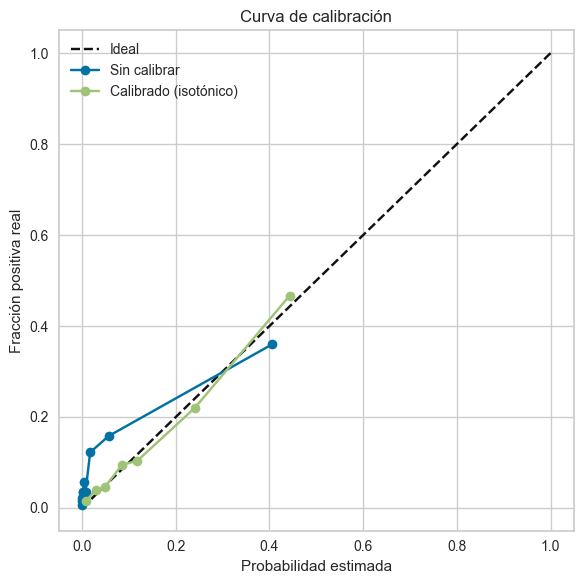

In [29]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
# Curvas de calibración
prob_true_raw, prob_pred_raw = calibration_curve(y_test2, y_proba_raw, n_bins=10, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(y_test2, y_proba_cal, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Ideal")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Sin calibrar")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrado (isotónico)")
plt.xlabel("Probabilidad estimada")
plt.ylabel("Fracción positiva real")
plt.title("Curva de calibración")
plt.legend()
plt.tight_layout()
plt.show()

La recta de calibrado es muy similar a la del ideal, en contraste a la curva sin calibrar.

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>